In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin
import seaborn as sns

from VerticalModelFunction import model as VerticalModel


# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'




In [53]:
# import NOAA data function
def Import_NOAA_Data(year, day):
    input_1 = year
    input_2 = day
    # -----------------NOAA-----------------------------------
    NOAA = [] #list to hold dataframes
    for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
        iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
        filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
        # print(filename) #print the filename being accessed
    
        try:
            file = urllib.request.urlopen(filename)
            data = file.read().decode('utf-8').split('\n') #read the file and split into lines
            #convert data to dataframe
            df = pd.DataFrame([row.split() for row in data[2:]])
            # print(dt)
            NOAA.append(df) #append dataframe to list
        except urllib.error.HTTPError:
            print()
            # print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    NOAAdir_ir_1 = NOAA[0][12]
    NOAAdir_ir_2 = NOAA[1][12]
    NOAAtemp = NOAA[0][38]
    # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
    # print(f'NOAAtemp: {NOAAtemp}')
    # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
    # concatenate the two days data with time correction
    NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))

    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    # diffuse irradiance
    NOAAdiff_ir_1 = NOAA[0][14]
    NOAAdiff_ir_2 = NOAA[1][14]
    
    # concatenate the two days data with time correction
    NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    NOAAup_ir_1 = NOAA[0][10] 
    NOAAup_ir_2 = NOAA[1][10]
    NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDTup_ir = NZDTup_ir.astype(float)
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula

    '''Solar Zenith Angle'''
    NOAA_Zenith_1 = NOAA[0][7] 
    NOAA_Zenith_2 = NOAA[1][7]
    NZDT_Zenith= pd.concat([NOAA_Zenith_1.iloc[660:1440], NOAA_Zenith_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDT_Zenith = NZDT_Zenith.astype(float)
    #remove nan values from NZDTup_ir 
    NZDT_Zenith[NZDT_Zenith == -9999.9] = np.nan
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time, NZDT_Zenith

In [54]:
# import panel data function
def Import_Panel_Data(year, day):
    input_1 = year
    input_2 = day
    # --------REAL PANEL DATA-------------
    #Read the CSV files based on user input
    file_101 = pd.read_csv(f"{InputPath}/spo_dev101_{input_1}_{input_2}.csv",delimiter=',')
    # file_103 = pd.read_csv(f"{InputPath}/spo_dev103_{input_1}_{input_2}.csv",delimiter=',')
    
    # Rename the Device ID column to voltage and Voltage to Current
    file_101.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True)
    # file_103.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True) # There is a mismatch in the file so voltage column contains current and Device ID contains voltage
    
    # Each file has the data for more than just the day it is. We want to remove these extra dataS
    
    def date2num(date_str): # Renamed 'date' to 'date_str' to avoid confusion with the datetime.date object
        # 26 # first conver the xxxx-xx-xx format to date(xxxx, xx, xx)
    
        # You can skip splitting the string and go directly to parsing:
        date_object = datetime.strptime(date_str, '%Y-%m-%d').date()
        
        # 29 # return the day of the year (%j) as an integer
        # The strftime method returns a string, so we convert it to an integer.
        return int(date_object.strftime('%j'))
    # print(f'DEBUG: {input_2}')
    date = file_101['Date']
    NumberDate = date.apply(date2num)
    mask_to_keep =  NumberDate <= int(input_2)
    file_101 = file_101[mask_to_keep]
    # print(f'DEBUG: {mask_to_keep}')
    # print(f'DEBUG: {NumberDate}')
    
    # date = file_103['Date']
    # NumberDate = date.apply(date2num)
    # mask_to_keep = NumberDate <= int(input_2)
    # file_103 = file_103[mask_to_keep]
    
    #Extract time, voltage and current data
    
    time_101 = file_101['Time']
    voltage_101 = file_101['V'] 
    current_101 = file_101['A'] 
    
    # time_103 = file_103['Time']
    # voltage_103 = file_103['V'] 
    # current_103 = file_103['A'] 
    
    power_101 = voltage_101 * current_101
    # power_103 = voltage_103 * current_103
    # -----------------------------

    # print(f'len(power_101) = {len(power_101)}')
    # return power_101, power_103, time_101, time_103
    return power_101, time_101, 
    

In [132]:
year = 25
day  = '345'

Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, NOAA_time, zenith = Import_NOAA_Data(year,day)
power_101_og, power_103_og = Import_Panel_Data(year, day)
# not using 103 but just in case:
power_103 = power_103_og
# get the time_101 from day 345 because it is complete
__,time_101 = Import_Panel_Data(25,365)
print(len(time_101))


power_101_og = power_101_og.to_numpy()
print(f'og: {len(power_101_og)}')
# print(len(power_101))
# if power_101 is too small, we pad with nan
if len(power_101_og) <= 2880:
    difference = 2880 - len(power_101_og)
    power_101 = power_101_og
    for i in np.arange(0,difference,1):
        power_101 = np.append(power_101, np.nan)

2880
og: 2879


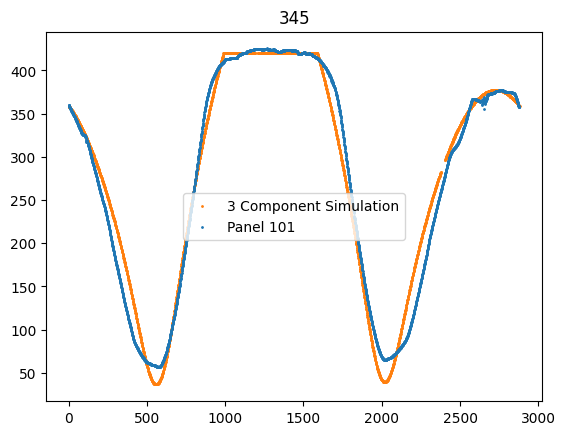

In [133]:
# Lets use our full 3 compnent vertical model function to see if that matches data well



time = np.linspace(0,1440*2,1440*2)
simulated_power = VerticalModel(Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [.25,0.06,0.04], 30, zenith, 109+180)

fig, ax = plt.subplots()

ax.scatter(time,np.repeat(simulated_power, 2), s = 1, color = 'tab:orange', label = '3 Component Simulation')
ax.scatter(time, power_101, s = 1, color = 'tab:blue', label = 'Panel 101')
ax.set_title(day)
ax.legend()
plt.show()







In [134]:
# We can directly fit 3 components as such
sharpness = 50
def Fit_Model(time, eff_dir, eff_diff, eff_upwelling):
    '''
    wrapping function for model
    '''
    effs = [eff_dir, eff_diff ,eff_upwelling]
    sim_power = VerticalModel(np.array(Direct_Irradiance), np.array(Diffuse_Irradiance), np.array(Upwelling_Irradiance), effs, sharpness, zenith, 109+180)
    sim_power_2880 = np.repeat(sim_power, 2)
    if len(sim_power_2880) > len(power_101_og):
        sim_power_data_length = sim_power_2880[:len(power_101_og)]
        # print(f'len(sim_power_data_length) = {len(sim_power_data_length)}')
        nanmask = ~np.isnan(power_101_og)
        # print(f'len(sim_power_data_length[nanmask]) = {len(sim_power_data_length[nanmask])}')
        sim_power_2880 = sim_power_data_length[nanmask]
    return sim_power_2880

# print(len(power_101))
# Using lmfit to fit
from lmfit import Model
from lmfit import fit_report
mod = Model(Fit_Model)

params = mod.make_params([.22,.01,.07]) # using the diff and upwelling from edges
# print(mod.param_names,mod.independent_vars)

params['eff_dir'].set(min=0, max=.3)     
params['eff_diff'].set(min=0, max=.3)
params['eff_upwelling'].set(min=0, max=.3)
# params['sharpness'].set(min = 1, max = 100)

nanmask = ~np.isnan(power_101_og)

DayArrayPowerLength = len(power_101_og[nanmask])
x = np.arange(0,DayArrayPowerLength,1)

# remove the nan values from power_101
y = power_101_og[nanmask]
# print(f'y = {len(y)}')

result = mod.fit(y, params,time = x, method='leastsq', nan_policy = 'omit')

# Print a comprehensive report of the results
# print(result.fit_report())

# Access the best-fit values
# print(f"Best Amplitude: {result.params['eff_dir'].value}")

fitted_dir_eff = result.params['eff_dir'].value
fitted_diff_eff = result.params['eff_diff'].value
fitted_upwelling_eff = result.params['eff_upwelling'].value
# fitted_sharpness = result.params['sharpness'].value


print()
print()
print(f'fitted_dir_eff =        {fitted_dir_eff}')
print(f'fitted_diff_eff =       {fitted_diff_eff}')
print(f'fitted_upwelling_eff =  {fitted_upwelling_eff}')
# print(f'fitted_sharpness = {fitted_sharpness}')

print(fit_report(result))




 - Adding parameter "eff_dir"
 - Adding parameter "eff_diff"
 - Adding parameter "eff_upwelling"


fitted_dir_eff =        0.2483510684411877
fitted_diff_eff =       0.2999997068750276
fitted_upwelling_eff =  0.017563594770861713
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 97
    # data points      = 2833
    # variables        = 3
    chi-square         = 1080742.23
    reduced chi-square = 381.887714
    Akaike info crit   = 16845.5421
    Bayesian info crit = 16863.3894
    R-squared          = nan
[[Variables]]
    eff_dir:        0.24835107 +/- 8.7868e-04 (0.35%) (init = 0)
    eff_diff:       0.29999971 +/- 0.04809180 (16.03%) (init = 0)
    eff_upwelling:  0.01756359 +/- 0.01108223 (63.10%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(eff_diff, eff_upwelling) = +0.9961
    C(eff_dir, eff_upwelling)  = -0.1683


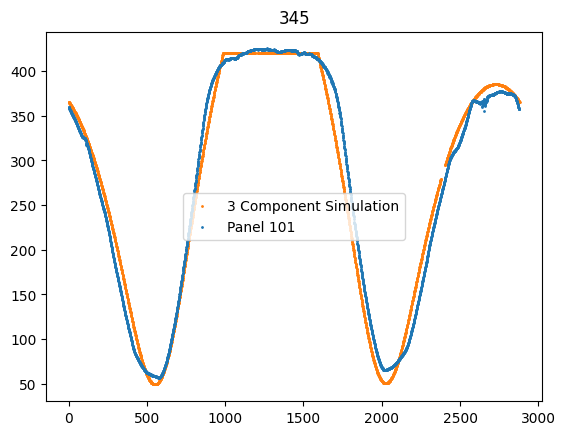

In [135]:

time = np.linspace(0,1440*2,1440*2)
simulated_power = VerticalModel(Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [fitted_dir_eff, fitted_diff_eff, fitted_upwelling_eff], sharpness, zenith, 109+180)

fig, ax = plt.subplots()

ax.scatter(time,np.repeat(simulated_power, 2), s = 1, color = 'tab:orange', label = '3 Component Simulation')
ax.scatter(time, power_101, s = 1, color = 'tab:blue', label = 'Panel 101')
ax.set_title(day)
ax.legend()
plt.show()

# But as we can see when we fit 3 components we find that since upweliing and diffuse are degenerate one goes very high and the other goes very low

In [136]:
# so another option is to fit 2 components: Direct + Isotropic and then try to split the isotropic in to diffuse + upwelling later


# sharpness = 50
def Fit_Model(time, eff_dir, eff_iso):
    '''
    wrapping function for model
    '''
    effs = [eff_dir, eff_iso ,eff_iso]
    sim_power = VerticalModel(np.array(Direct_Irradiance), np.array(Diffuse_Irradiance), np.array(Upwelling_Irradiance), effs, sharpness, zenith, 112+180)
    sim_power_2880 = np.repeat(sim_power, 2)
    if len(sim_power_2880) > len(power_101_og):
        sim_power_data_length = sim_power_2880[:len(power_101_og)]
        # print(f'len(sim_power_data_length) = {len(sim_power_data_length)}')
        nanmask = ~np.isnan(power_101_og)
        # print(f'len(sim_power_data_length[nanmask]) = {len(sim_power_data_length[nanmask])}')
        sim_power_2880 = sim_power_data_length[nanmask]
    return sim_power_2880

# print(len(power_101))
# Using lmfit to fit
from lmfit import Model
from lmfit import fit_report
mod = Model(Fit_Model)

params = mod.make_params([.22,.01,.07]) # using the diff and upwelling from edges
# print(mod.param_names,mod.independent_vars)

params['eff_dir'].set(min=0, max=.3)     
params['eff_iso'].set(min=0, max=.3)

# params['eff_diff'].set(min=0, max=.3)
# params['eff_upwelling'].set(min=0, max=.3)
# params['sharpness'].set(min = 1, max = 100)

nanmask = ~np.isnan(power_101_og)

DayArrayPowerLength = len(power_101_og[nanmask])
x = np.arange(0,DayArrayPowerLength,1)

# remove the nan values from power_101
y = power_101_og[nanmask]
# print(f'y = {len(y)}')

result = mod.fit(y, params,time = x, method='leastsq', nan_policy = 'omit')

# Print a comprehensive report of the results
# print(result.fit_report())

# Access the best-fit values
# print(f"Best Amplitude: {result.params['eff_dir'].value}")

fitted_dir_eff = result.params['eff_dir'].value
fitted_iso_eff = result.params['eff_iso'].value
# fitted_upwelling_eff = result.params['eff_upwelling'].value
# fitted_sharpness = result.params['sharpness'].value


print()
print()
print(f'fitted_dir_eff =        {fitted_dir_eff}')
print(f'fitted_iso_eff =       {fitted_iso_eff}')
# print(f'fitted_upwelling_eff =  {fitted_upwelling_eff}')
# print(f'fitted_sharpness = {fitted_sharpness}')

# print(fit_report(result))








 - Adding parameter "eff_dir"
 - Adding parameter "eff_iso"


fitted_dir_eff =        0.24385675057723757
fitted_iso_eff =       0.05983977583492165


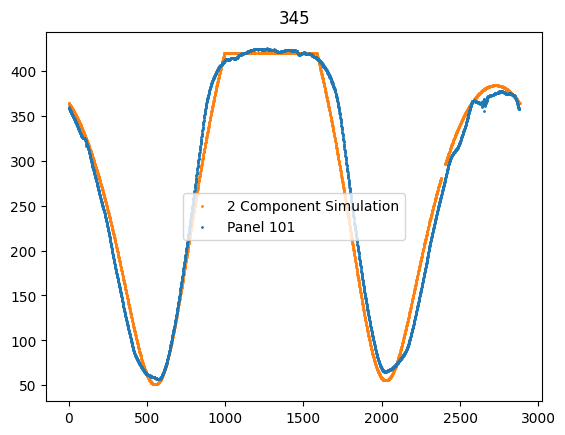

In [137]:

time = np.linspace(0,1440*2,1440*2)
simulated_power = VerticalModel(Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [fitted_dir_eff, fitted_iso_eff, fitted_iso_eff], sharpness, zenith, 109+180)

fig, ax = plt.subplots()

ax.scatter(time,np.repeat(simulated_power, 2), s = 1, color = 'tab:orange', label = '2 Component Simulation')
ax.scatter(time, power_101, s = 1, color = 'tab:blue', label = 'Panel 101')
ax.set_title(day)
ax.legend()
plt.show()

# But as we can see when we fit 3 components we find that since upweliing and diffuse are degenerate one goes very high and the other goes very low

0.05983977583492165
solved for upwelling irradiance: -0.23
solved for diffuse irradiance: 0.29


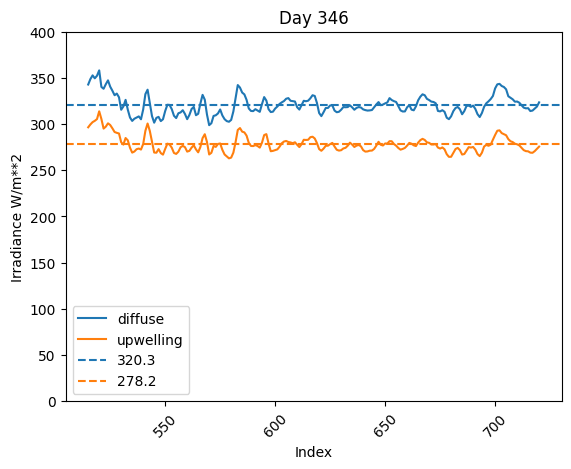

In [142]:
# Now let's try and break the isotropic component in to diffuse and upwelling

# We will do this by using day 346. During this day the direct irradiance went to 0 because of clouds, leaving only the diffuse and upwelling


# Lets consider the part of day 346 where the dirrect irradiance is 0
# This is inbetween indecies 514 and 720 to be safe

eff_isotropic = fitted_iso_eff

Direct_Irradiance_346, Diffuse_Irradiance_346, Upwelling_Irradiance_346,_ , zenith_346 = Import_NOAA_Data(25,346)
power_101_346,_ = Import_Panel_Data(25, 346)
start_346_range = 514
stop_346_range = 720
Upwelling_Irradiance_range_346 = Upwelling_Irradiance_346[start_346_range:stop_346_range]
Diffuse_Irradiance_range_346 = Diffuse_Irradiance_346[start_346_range:stop_346_range]
Upwelling_Irradiance_range_346_mean = np.mean(Upwelling_Irradiance_range_346)
Diffuse_Irradiance_range_346_mean = np.mean(Diffuse_Irradiance_range_346)


power_101_range_346 = np.nanmean(power_101_346[2*start_346_range:2*stop_346_range])
# power_101_range_346 = 90

# print(power_101_range_346)
print(eff_isotropic)
# Power = Area*(eff_up*Irr_up + ((eff_iso-eff_up)*Irr_diff)) using the assumption
# Solving for eff_up with algebra: 
# eff_up = (power/area - Irr_diff*eff_iso)/(Irr_up - Irr_diff)


eff_up_found = (power_101_range_346/(Area*1.7) - Diffuse_Irradiance_range_346_mean*eff_isotropic)/(Upwelling_Irradiance_range_346_mean - Diffuse_Irradiance_range_346_mean)
print(f'solved for upwelling irradiance: {np.round(eff_up_found, 2)}')
print(f'solved for diffuse irradiance: {np.round(eff_isotropic - eff_up_found, 2)}')

fig, ax1 = plt.subplots()
# ax1.scatter(np.linspace(0,1440, 1440),Direct_Irradiance_range_346, s = 1)
ax1.plot(np.arange(start_346_range,stop_346_range, 1)+1,Diffuse_Irradiance_range_346, label = 'diffuse')
ax1.plot(np.arange(start_346_range,stop_346_range, 1)+1,Upwelling_Irradiance_range_346, label = 'upwelling')
ax1.axhline(y = Diffuse_Irradiance_range_346_mean, linestyle = '--', color = 'tab:blue', label = f'{np.round(Diffuse_Irradiance_range_346_mean, 1)}')
ax1.axhline(y = Upwelling_Irradiance_range_346_mean, linestyle = '--', color = 'tab:orange', label = f'{np.round(Upwelling_Irradiance_range_346_mean, 1)}')
ax1.legend()
# ax1.set_xticks(np.linspace(0, 1440, 15))
ax1.set_xlabel(f'Index')
ax1.set_ylabel(f'Irradiance W/m**2')
ax1.set_title(f'Day {346}')
ax1.set_ylim(0,400)
ax1.tick_params(axis='x', labelrotation=45)






